In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Unemployment in India.csv")

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [17]:
df.isnull().sum()

,0
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,28


In [18]:
df = df.dropna()

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Area                                        0
dtype: int64


In [19]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [20]:
region_avg = df.groupby("Region")[" Estimated Unemployment Rate (%)"].mean().sort_values(ascending=False)

region_avg

,Estimated Unemployment Rate (%)
Region,
Tripura,28.350357
Haryana,26.283214
Jharkhand,20.585000
Bihar,18.918214
Himachal Pradesh,18.540357
Delhi,16.495357
Jammu & Kashmir,16.188571
Chandigarh,15.991667
Rajasthan,14.058214


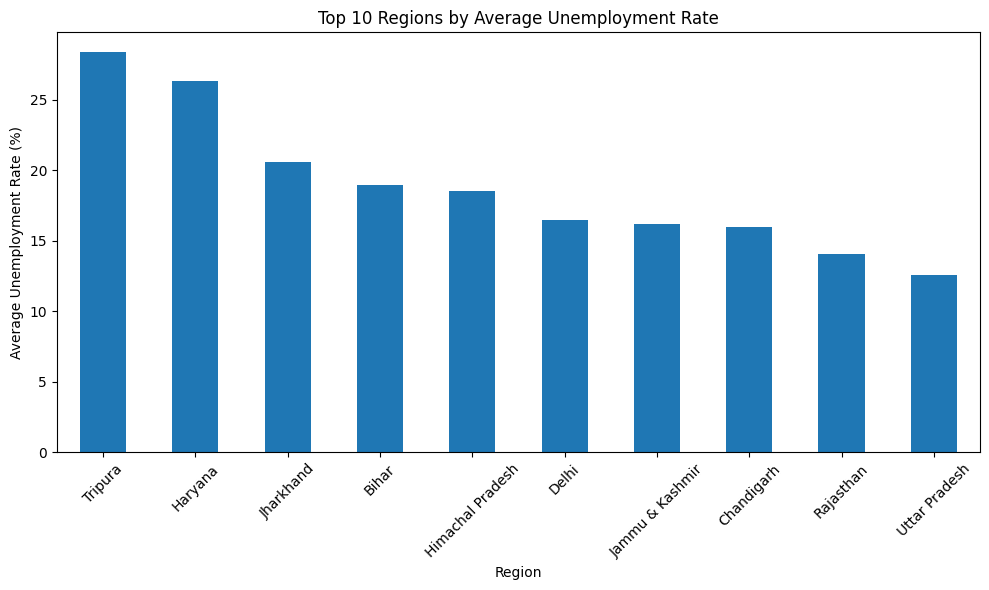

In [21]:
top_10 = region_avg.head(10)

plt.figure(figsize=(10, 6))
top_10.plot(kind="bar")

plt.title("Top 10 Regions by Average Unemployment Rate")
plt.xlabel("Region")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1468/1672373432.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[" Date"] = pd.to_datetime(df[" Date"])


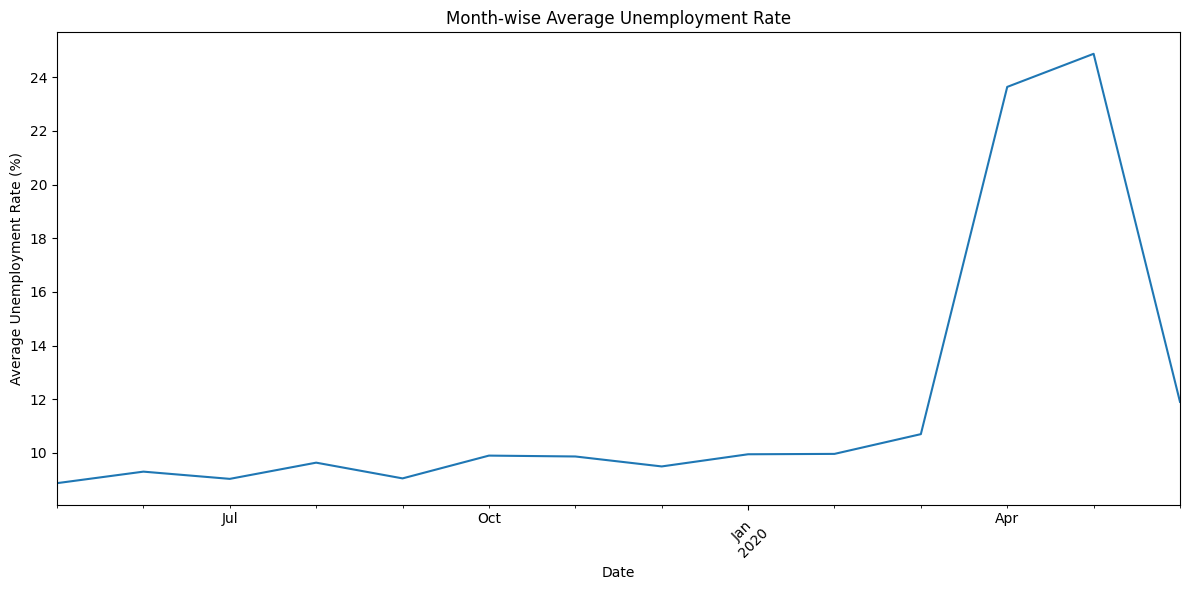

In [22]:
df[" Date"] = pd.to_datetime(df[" Date"])

monthly_avg = df.groupby(" Date")[" Estimated Unemployment Rate (%)"].mean()

plt.figure(figsize=(12, 6))
monthly_avg.plot()

plt.title("Month-wise Average Unemployment Rate")
plt.xlabel("Date")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Area
Rural    10.324791
Urban    13.166614
Name:  Estimated Unemployment Rate (%), dtype: float64


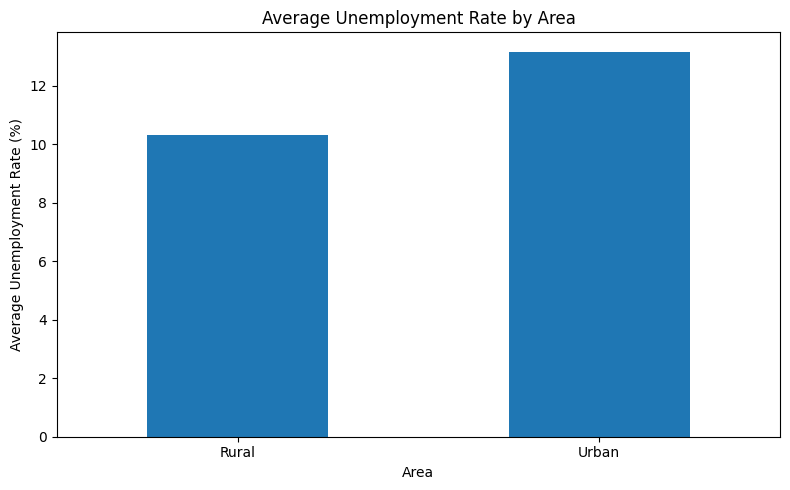

In [23]:
area_avg = df.groupby("Area")[" Estimated Unemployment Rate (%)"].mean()

print(area_avg)

plt.figure(figsize=(8, 5))
area_avg.plot(kind="bar")

plt.title("Average Unemployment Rate by Area")
plt.xlabel("Area")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

 Date
2019     9.399047
2020    15.101581
Name:  Estimated Unemployment Rate (%), dtype: float64


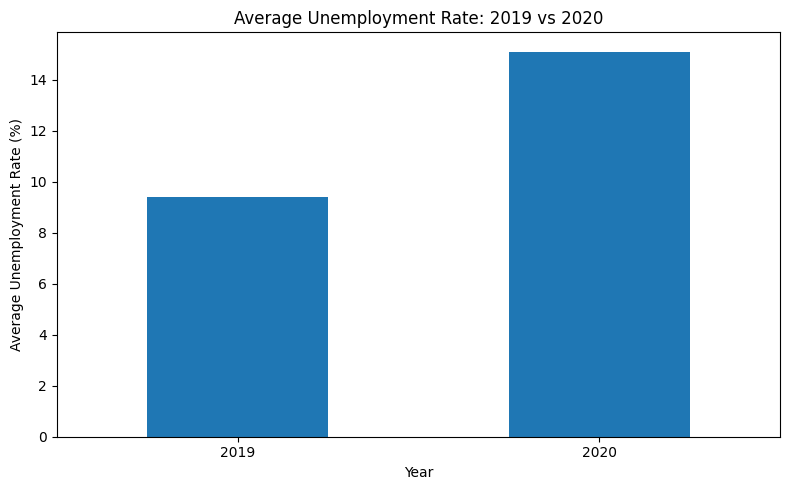

In [24]:
covid_data = df[(df[" Date"].dt.year >= 2019) & (df[" Date"].dt.year <= 2020)]

covid_avg = covid_data.groupby(covid_data[" Date"].dt.year)[" Estimated Unemployment Rate (%)"].mean()

print(covid_avg)

plt.figure(figsize=(8, 5))
covid_avg.plot(kind="bar")

plt.title("Average Unemployment Rate: 2019 vs 2020")
plt.xlabel("Year")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


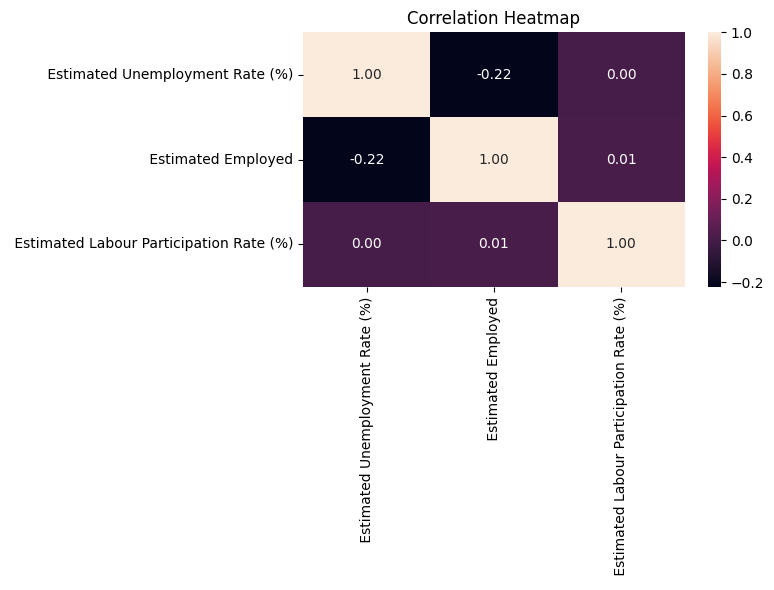

In [25]:
correlation = df[
    [
        " Estimated Unemployment Rate (%)",
        " Estimated Employed",
        " Estimated Labour Participation Rate (%)"
    ]
].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, fmt=".2f")

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

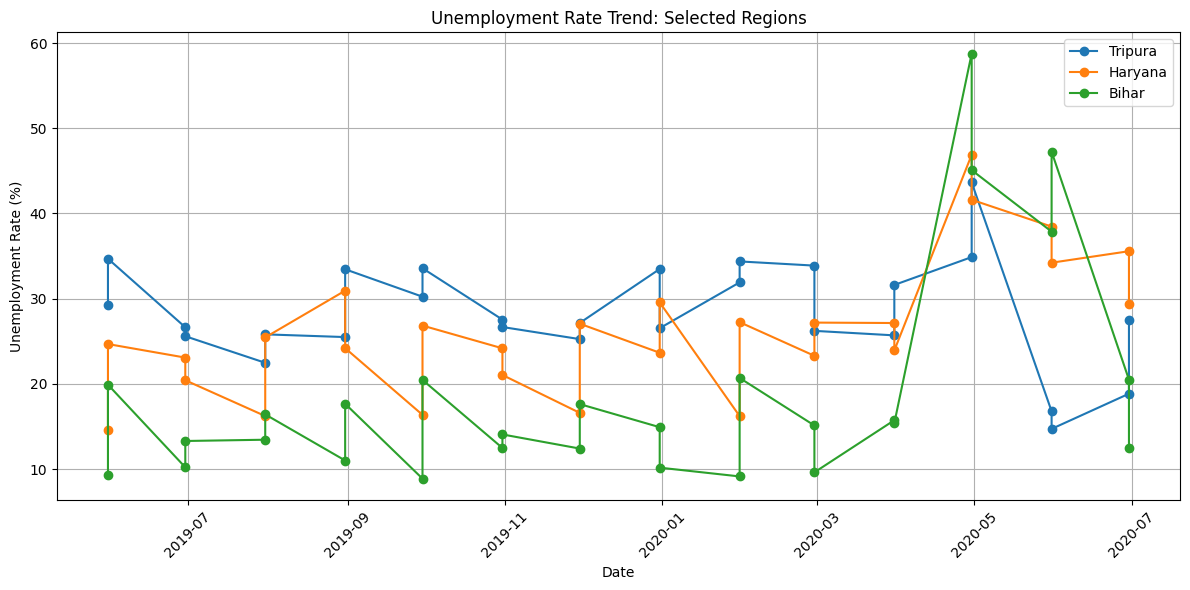

In [26]:
selected_regions = ["Tripura", "Haryana", "Bihar"]

plt.figure(figsize=(12, 6))

for region in selected_regions:
    region_data = df[df["Region"] == region].sort_values(" Date")
    plt.plot(
        region_data[" Date"],
        region_data[" Estimated Unemployment Rate (%)"],
        marker="o",
        label=region
    )

plt.title("Unemployment Rate Trend: Selected Regions")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

In [27]:
print("Key Observations:")
print("1. Tripura has the highest average unemployment rate among the regions analyzed.")
print("2. Unemployment rates vary considerably across different regions.")
print("3. The unemployment trend changes over time, with noticeable variation during the COVID-19 period.")
print("4. Urban and rural areas show differences in their average unemployment rates.")
print("5. The COVID-19 period had a noticeable effect on unemployment levels.")

Key Observations:
1. Tripura has the highest average unemployment rate among the regions analyzed.
2. Unemployment rates vary considerably across different regions.
3. The unemployment trend changes over time, with noticeable variation during the COVID-19 period.
4. Urban and rural areas show differences in their average unemployment rates.
5. The COVID-19 period had a noticeable effect on unemployment levels.


In [28]:
print("Conclusion:")
print("The analysis shows significant differences in unemployment rates across regions in India.")
print("Tripura recorded the highest average unemployment rate among the regions analyzed.")
print("Unemployment rates also changed over time, with noticeable changes during the COVID-19 period.")
print("The analysis helps identify regional and time-based unemployment patterns.")

Conclusion:
The analysis shows significant differences in unemployment rates across regions in India.
Tripura recorded the highest average unemployment rate among the regions analyzed.
Unemployment rates also changed over time, with noticeable changes during the COVID-19 period.
The analysis helps identify regional and time-based unemployment patterns.
